# klasifikasi jenis kismis (raisin)

## Data Understanding


### Sumber dataset

https://archive.ics.uci.edu/dataset/850/raisin

Citations:

* Raisin https://archive.ics.uci.edu/dataset/850/raisin

### Penjelasan Fitur dan Variabel

Dataset ini berkaitan dengan pengklasifikasian dua jenis kismis, yaitu Kecimen dan Besni, berdasarkan karakteristik morfologis yang diperoleh melalui analisis citra (image processing) pada gambar biji kismis.

Dataset ini berisi 900 sampel yang diambil dari kedua jenis kismis tersebut secara seimbang (masing-masing 450), dan setiap sampel diekstrak menjadi sejumlah fitur numerik untuk membedakan bentuk fisik dari tiap jenis kismis.

Dataset ini dikembangkan melalui studi penelitian dan pemrosesan citra digital untuk memperoleh parameter morfologis seperti ukuran, bentuk, dan kontur permukaan. Dataset ini banyak digunakan dalam tugas klasifikasi citra dan machine learning, khususnya yang berkaitan dengan pengolahan hasil pertanian.

Tujuan dari dataset ini adalah untuk membangun model klasifikasi berbasis supervised learning yang dapat memprediksi jenis kismis hanya berdasarkan data morfologis biji yang dianalisis dari gambar.

Dataset ini cocok untuk studi klasifikasi, eksplorasi data visual, serta pemodelan machine learning dengan fitur numerik hasil ekstraksi citra.

Fitur yang digunakan:
1. Area	Luas wilayah biji kismis dalam piksel (jumlah total piksel objek). Mewakili ukuran total.
2. MajorAxisLength	Panjang sumbu utama dari elips yang cocok dengan kontur biji. Menggambarkan panjang maksimum.
3. MinorAxisLength	Panjang sumbu minor dari elips kontur biji. Menggambarkan lebar relatif.
4. Eccentricity	Mengukur keovalan biji, bernilai antara 0 (lingkaran sempurna) hingga 1 (elips sangat lonjong).
5. ConvexArea	Luas bentuk cembung (convex hull) yang membungkus biji. Selalu ≥ Area.
6. Extent	Rasio antara Area objek dan bounding box. Mencerminkan seberapa "penuh" objek dalam kotaknya.
7. Perimeter	Panjang total kontur atau tepi objek biji kismis.
8. Class	Label jenis kismis: Kecimen atau Besni. (Target untuk klasifikasi)

### Eksplorasi data


Dataset ini tidak ada missing value

### Visualisasi data

In [1]:
pip install ucimlrepo

In [2]:
from ucimlrepo import fetch_ucirepo

# fetch dataset
raisin = fetch_ucirepo(id=850)

# data (as pandas dataframes)
X = raisin.data.features
y = raisin.data.targets

# metadata
print(raisin.metadata)

# variable information
print(raisin.variables)


{'uci_id': 850, 'name': 'Raisin', 'repository_url': 'https://archive.ics.uci.edu/dataset/850/raisin', 'data_url': 'https://archive.ics.uci.edu/static/public/850/data.csv', 'abstract': 'Images of the Kecimen and Besni raisin varieties were obtained with CVS. A total of 900 raisins were used, including 450 from both varieties, and 7 morphological features were extracted.', 'area': 'Biology', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 900, 'num_features': 7, 'feature_types': ['Real', 'Integer'], 'demographics': [], 'target_col': ['Class'], 'index_col': None, 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 2020, 'last_updated': 'Fri Jan 05 2024', 'dataset_doi': '10.24432/C5660T', 'creators': ['İ̇lkay Çinar', 'Murat Koklu', 'Sakir Tasdemir'], 'intro_paper': {'ID': 261, 'type': 'NATIVE', 'title': 'Kuru Üzüm Tanelerinin Makine Görüşü ve Yapay Zeka Yöntemleri Kullanılarak Sınıflandırılması', 'authors': 'İ̇lkay Çinar

In [4]:
import pandas as pd

# Membaca file Raisin Dataset
# df_raisin = pd.read_excel("Raisin_Dataset.xlsx")

# Use the dataframe fetched from ucimlrepo
df_raisin = X.copy() # Use the features dataframe X as the main dataframe

# Menampilkan jumlah baris dan isi dataset
print("Total baris dataset ini adalah =", len(df_raisin))
print("Visualisasi dataset Raisin")
print(df_raisin)

Total baris dataset ini adalah = 900
Visualisasi dataset Raisin
      Area  MajorAxisLength  MinorAxisLength  Eccentricity  ConvexArea  \
0    87524       442.246011       253.291155      0.819738       90546   
1    75166       406.690687       243.032436      0.801805       78789   
2    90856       442.267048       266.328318      0.798354       93717   
3    45928       286.540559       208.760042      0.684989       47336   
4    79408       352.190770       290.827533      0.564011       81463   
..     ...              ...              ...           ...         ...   
895  83248       430.077308       247.838695      0.817263       85839   
896  87350       440.735698       259.293149      0.808629       90899   
897  99657       431.706981       298.837323      0.721684      106264   
898  93523       476.344094       254.176054      0.845739       97653   
899  85609       512.081774       215.271976      0.907345       89197   

       Extent  Perimeter  
0    0.758651   1184

In [5]:
# Simpan ke file CSV
df_raisin.to_csv('raisin.csv', index=False)

## Preprocessing Data

### Encoding

Karena model Decision Tree hanya menerima input dalam bentuk numerik, maka kolom target Class yang berisi nilai kategorikal ("Besni" dan "Kecimen") perlu diubah menjadi angka. Untuk itu, digunakan teknik Label Encoding agar label kategorikal dapat dikenali oleh model.

In [7]:
from sklearn.preprocessing import LabelEncoder
import pandas as pd

# Combine features (X) and target (y) for encoding
data = pd.concat([X, y], axis=1)

# Encoding kolom Class (target)
le = LabelEncoder()
data['class_encoded'] = le.fit_transform(data['Class'])

# Cek hasil encoding (misalnya: Besni=0, Kecimen=1)
print("Mapping Label Class:")
for label, encoded in zip(le.classes_, le.transform(le.classes_)):
    print(f"{label} → {encoded}")

display(data.head())

Mapping Label Class:
Besni → 0
Kecimen → 1


,Area,MajorAxisLength,MinorAxisLength,Eccentricity,ConvexArea,Extent,Perimeter,Class,class_encoded
0,87524,442.246011,253.291155,0.819738,90546,0.758651,1184.040,Kecimen,1
1,75166,406.690687,243.032436,0.801805,78789,0.684130,1121.786,Kecimen,1
2,90856,442.267048,266.328318,0.798354,93717,0.637613,1208.575,Kecimen,1
3,45928,286.540559,208.760042,0.684989,47336,0.699599,844.162,Kecimen,1
4,79408,352.190770,290.827533,0.564011,81463,0.792772,1073.251,Kecimen,1


### Pemilihan Fitur

In [8]:
# Pemisahan fitur dan target
X = data.drop(columns=['Class', 'class_encoded'])  # fitur numerik
y = data['class_encoded']                          # target yang sudah diencoding

# Cek bentuk data
print("Jumlah fitur:", X.shape[1])
print("Jumlah data:", X.shape[0])
print("Fitur yang digunakan:", list(X.columns))

Jumlah fitur: 7
Jumlah data: 900
Fitur yang digunakan: ['Area', 'MajorAxisLength', 'MinorAxisLength', 'Eccentricity', 'ConvexArea', 'Extent', 'Perimeter']


### Splitting Data

In [10]:
from sklearn.model_selection import train_test_split

# Split dataset menjadi data latih dan data uji
X_train, X_test, y_train, y_test = train_test_split(
    X, y,                  # fitur dan target
    test_size=0.2,         # 20% untuk data uji
    random_state=42        # agar hasil konsisten
)

# Cek ukuran data hasil split
print("Jumlah data latih  :", len(X_train))
print("Jumlah data uji    :", len(X_test))

Jumlah data latih  : 720
Jumlah data uji    : 180


### Visualisasi Data setelah Normalisasi

In [11]:
print(data)

      Area  MajorAxisLength  MinorAxisLength  Eccentricity  ConvexArea  \
0    87524       442.246011       253.291155      0.819738       90546   
1    75166       406.690687       243.032436      0.801805       78789   
2    90856       442.267048       266.328318      0.798354       93717   
3    45928       286.540559       208.760042      0.684989       47336   
4    79408       352.190770       290.827533      0.564011       81463   
..     ...              ...              ...           ...         ...   
895  83248       430.077308       247.838695      0.817263       85839   
896  87350       440.735698       259.293149      0.808629       90899   
897  99657       431.706981       298.837323      0.721684      106264   
898  93523       476.344094       254.176054      0.845739       97653   
899  85609       512.081774       215.271976      0.907345       89197   

       Extent  Perimeter    Class  class_encoded  
0    0.758651   1184.040  Kecimen              1  
1    0.68

In [12]:
# Simpan ke file CSV
data.to_csv('raisin.csv', index=False)

## Modelling

Modeling merupakan proses pembuatan dan pengujian model statistik atau matematis yang digunakan untuk menggambarkan dan menganalisis pola atau hubungan dalam data. Tujuan utama dari pemodelan dalam data mining adalah untuk mengidentifikasi pola yang berguna atau prediksi yang akurat dari data yang tersedia.

### Modelling Klasifikasi Jenis Kismis (Raisin) menggunakan Decision Tree


1. Tujuan Pemodelan

Pemodelan ini bertujuan untuk mengklasifikasikan jenis kismis berdasarkan fitur morfologis yang diperoleh dari citra biji kismis. Setiap jenis kismis memiliki karakteristik ukuran dan bentuk yang khas, yang dapat diekstraksi menjadi fitur numerik melalui teknik pengolahan citra (image processing).

Kategori kelas target dalam model ini terdiri dari dua jenis kismis:

- Besni

- Kecimen

Model klasifikasi yang digunakan adalah Decision Tree Classifier, yaitu metode supervised learning berbasis pohon keputusan. Setiap cabang dalam pohon mewakili keputusan berdasarkan fitur morfologis seperti ukuran, bentuk, dan kepadatan biji, sedangkan setiap daun menunjukkan hasil klasifikasi jenis kismis.hasil klasifikasi gender.

2. Pembagian Dataset: Data Latih dan Data Uji

Langkah awal dalam pemodelan adalah membagi dataset menjadi dua bagian utama:

* Data Latih (Training Set): digunakan untuk melatih model agar mengenali pola dalam data.
* Data Uji (Testing Set): digunakan untuk menguji akurasi model terhadap data baru yang belum pernah dilihat sebelumnya.

Dalam eksperimen ini digunakan pembagian data dengan rasio 80:20, artinya 80% data untuk pelatihan dan 20% untuk pengujian. Pemilihan rasio ini fleksibel, tergantung pada ukuran dan distribusi dataset.

3. Pra-Pemrosesan Data

Sebelum digunakan dalam model klasifikasi, dilakukan beberapa langkah pra-pemrosesan (preprocessing) terhadap data:

- Label Encoding pada kolom Class, yang merupakan target klasifikasi, untuk mengubah nilai kategorikal ('Besni', 'Kecimen') menjadi nilai numerik (0, 1).

- Tidak diperlukan ekstraksi atau encoding pada fitur lainnya karena semua fitur (Area, Eccentricity, Extent, dll.) sudah dalam bentuk numerik dan siap digunakan oleh algoritma Decision Tree.

4. Pelatihan Model Decision Tree

Model dilatih menggunakan algoritma Decision Tree Classifier dari pustaka sklearn dengan parameter default, namun dapat disesuaikan untuk mencegah overfitting. Beberapa parameter yang bisa diatur:

- Kriteria: gini (digunakan untuk mengukur ketidakmurnian suatu node)

- Kedalaman maksimum (max_depth): dapat diatur sesuai kebutuhan agar pohon tidak terlalu dalam dan menjaga generalisasi model.

Pohon keputusan dibangun secara rekursif dengan membagi data berdasarkan fitur yang paling membantu dalam membedakan antara jenis kismis Besni dan Kecimen.

5. Evaluasi Model

Setelah pelatihan, model dievaluasi menggunakan metrik berikut:

* Akurasi: proporsi prediksi yang benar dibandingkan total data uji.
* Classification Report: memberikan metrik evaluasi seperti precision, recall, dan F1-score untuk masing-masing kelas (Besni dan Kecimen).
* Confusion Matrix: untuk melihat bagaimana prediksi model tersebar di antara kelas-kelas sebenarnya.
* Visualisasi Struktur Pohon: menampilkan struktur pohon keputusan, urutan fitur yang digunakan, nilai split, dan label prediksi di setiap node.

6. Prediksi dan Interpretasi

Model yang telah dilatih dapat digunakan untuk:

- Memprediksi jenis kismis baru berdasarkan fitur morfologis hasil ekstraksi citra.

- Menganalisis fitur yang paling berpengaruh, misalnya fitur Eccentricity atau MinorAxisLength dapat memiliki kontribusi besar dalam membedakan jenis kismis.

Visualisasi pohon dapat digunakan untuk memahami urutan keputusan yang diambil oleh model dalam mengklasifikasikan data.


Akurasi: 0.8388888888888889

=== Classification Report ===
              precision    recall  f1-score   support

       Besni       0.85      0.80      0.83        86
     Kecimen       0.83      0.87      0.85        94

    accuracy                           0.84       180
   macro avg       0.84      0.84      0.84       180
weighted avg       0.84      0.84      0.84       180



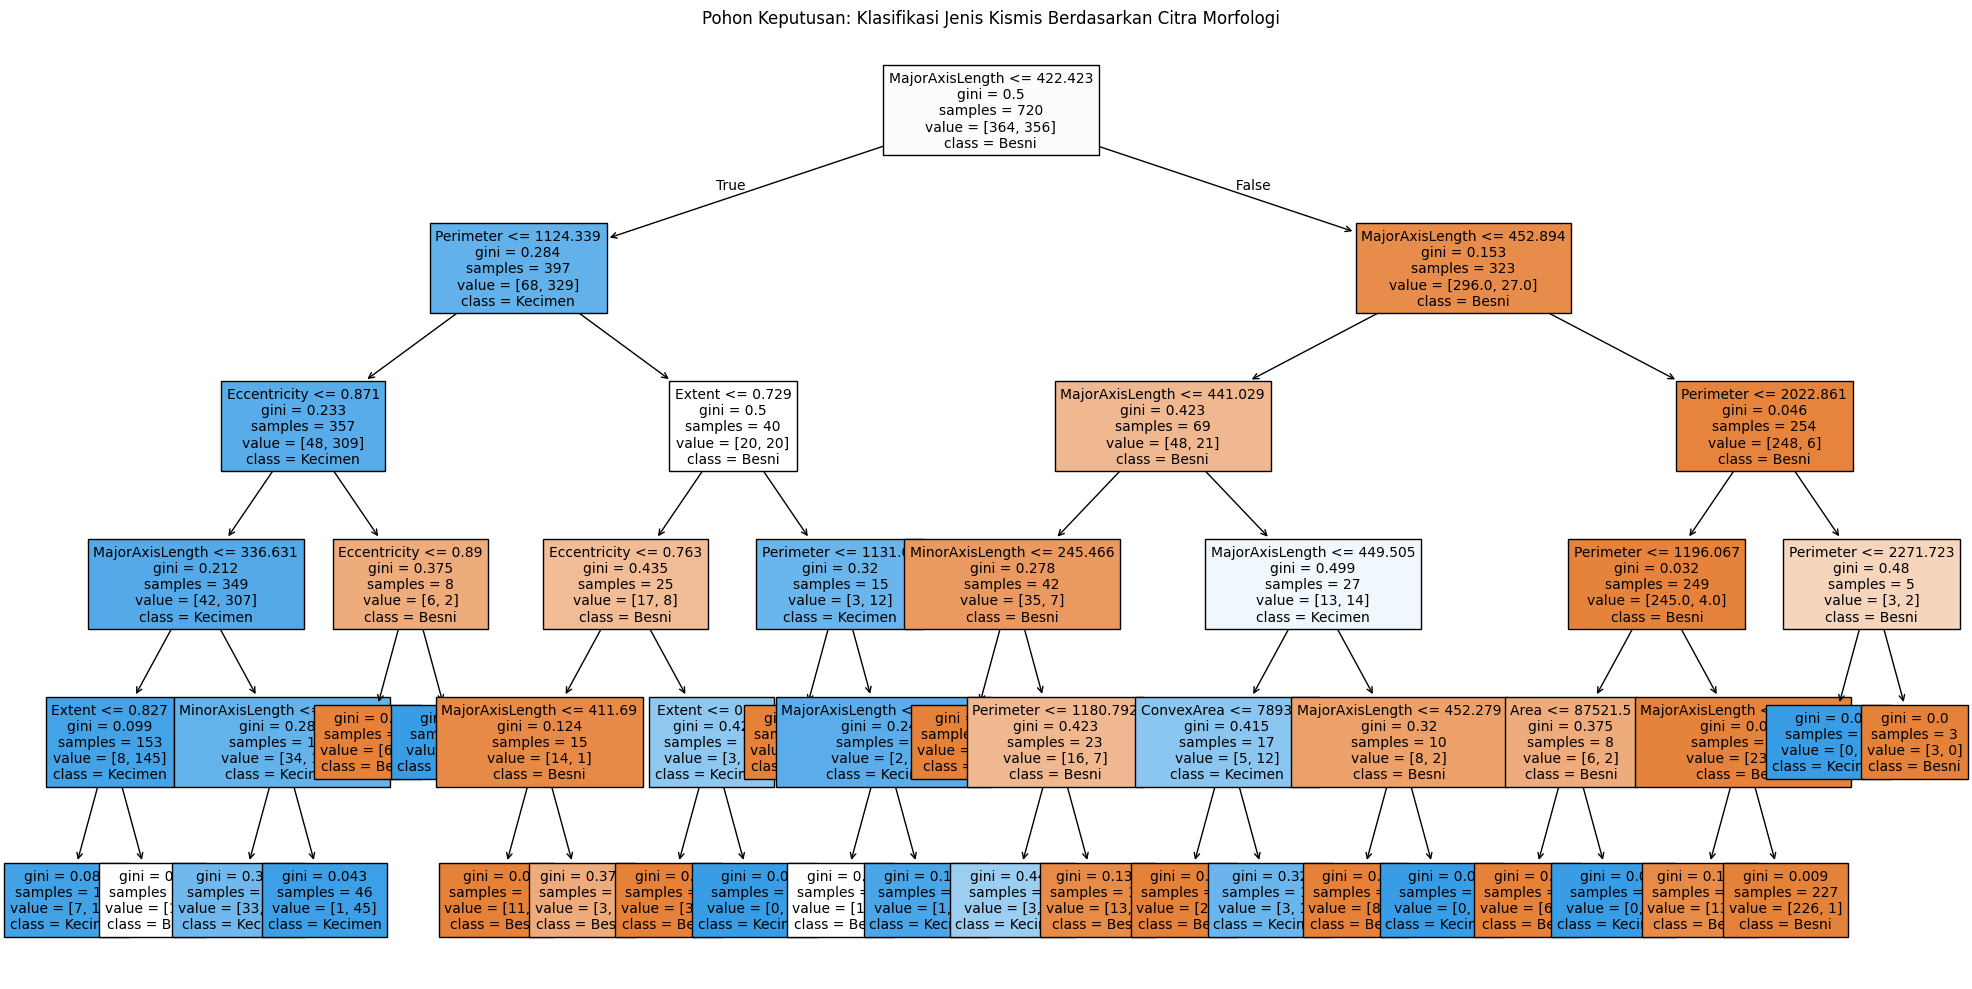

In [14]:
# === 6. Training Decision Tree ===
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import classification_report, accuracy_score
import matplotlib.pyplot as plt

# Membuat dan melatih model Decision Tree
clf = DecisionTreeClassifier(criterion='gini', max_depth=5, random_state=42)
clf.fit(X_train, y_train)

# === 7. Evaluasi Model ===
# Melakukan prediksi terhadap data uji
y_pred = clf.predict(X_test)

# Menampilkan akurasi dan laporan klasifikasi
print("Akurasi:", accuracy_score(y_test, y_pred))
print("\n=== Classification Report ===")
print(classification_report(y_test, y_pred, target_names=le.classes_))

# === 8. Visualisasi Pohon Keputusan ===
# Visualisasi pohon keputusan
plt.figure(figsize=(20, 10))
plot_tree(
    clf,
    feature_names=X.columns,
    class_names=le.classes_,  # class target: ['Besni', 'Kecimen']
    filled=True,
    fontsize=10
)
plt.title("Pohon Keputusan: Klasifikasi Jenis Kismis Berdasarkan Citra Morfologi")
plt.tight_layout()
plt.show()

### Modelling Klasifikasi Jenis Kismis (Raisin) menggunakan Naive Bayes

1. Tujuan Pemodelan**

Pemodelan ini bertujuan untuk mengklasifikasikan jenis kismis menjadi salah satu dari dua kategori: Besni atau Kecimen, berdasarkan karakteristik morfologis biji kismis yang diperoleh dari citra menggunakan image processing.

Model klasifikasi yang digunakan adalah Naive Bayes, sebuah metode probabilistik berbasis Teorema Bayes dengan asumsi bahwa fitur-fitur bersifat saling independen. Meskipun sederhana, model ini efisien dan cukup akurat untuk kasus klasifikasi dengan fitur numerik yang telah dikonversi ke dalam bentuk diskrit.

2. Pembagian Dataset: Data Latih dan Data Uji**

Dataset dibagi menjadi dua bagian:

* **Data Latih (Training Set)**: digunakan untuk membangun model dan menghitung probabilitas.
* **Data Uji (Testing Set)**: digunakan untuk menguji keakuratan model pada data yang belum pernah dilihat sebelumnya.

Untuk eksperimen ini digunakan pembagian data dengan rasio **80% data latih** dan **20% data uji**, yang umum digunakan untuk memastikan keseimbangan antara pelatihan dan evaluasi.

3. Pra-Pemrosesan Data**

Sebelum model dilatih, dilakukan beberapa tahapan pra-pemrosesan (preprocessing):
- Label Encoding pada kolom Class untuk mengubah nilai kategorikal ('Besni', 'Kecimen') menjadi nilai numerik (0, 1).

- Fitur numerik seperti Area, Eccentricity, Perimeter, dll., diubah menjadi bentuk diskrit (kategori) karena model Naive Bayes (CategoricalNB) hanya menerima input dalam bentuk kategorikal.

- Diskretisasi dilakukan dengan cara membagi nilai numerik menjadi beberapa bin (kategori) menggunakan metode seperti uniform binning atau quantile binning (misalnya dengan pd.cut() atau KBinsDiscretizer dari sklearn).

4. Pelatihan Model Naive Bayes**

Model dilatih menggunakan algoritma Categorical Naive Bayes (CategoricalNB), yang dirancang untuk menangani data kategorikal (diskrit). Model ini menghitung probabilitas kemunculan setiap kombinasi fitur dalam masing-masing kelas kismis, lalu memprediksi kelas dengan probabilitas tertinggi.

Asumsi independensi antar fitur digunakan dalam perhitungan:

$$
P(\text{Class} \mid \text{Fitur}) \propto P(\text{Class}) \prod P(\text{Fitur}_i \mid \text{Class})
$$

Di mana:

- Class adalah jenis kismis (Besni atau Kecimen)

- Fitur_i adalah fitur morfologis yang telah didiskretisasi

5. Evaluasi Model**

Setelah pelatihan, model dievaluasi menggunakan beberapa metrik umum klasifikasi:

- Akurasi: Persentase prediksi yang benar dari total data uji

- Classification Report, yang mencakup:

- Precision: Tingkat ketepatan model dalam memprediksi setiap kelas

- Recall: Kemampuan model mengenali semua contoh dari setiap kelas

- F1-Score: Rata-rata harmonik dari precision dan recall

- Confusion Matrix: Menunjukkan jumlah prediksi yang benar dan salah untuk masing-masing kelas. Matrix ini bisa divisualisasikan dalam bentuk heatmap untuk memudahkan analisis.

6. Prediksi dan Interpretasi**

Setelah model dilatih dan dievaluasi, dapat digunakan untuk:

- Memprediksi jenis kismis baru berdasarkan fitur morfologis hasil pengukuran atau ekstraksi dari gambar.

- Menganalisis fitur yang paling berkontribusi dalam klasifikasi berdasarkan probabilitas kondisional yang dihitung oleh model.

- Menilai probabilitas prediksi, misalnya untuk thresholding dalam sistem penyortiran otomatis.

Kesimpulan**

Model Naive Bayes sangat cocok digunakan dalam klasifikasi jenis kismis karena:

- Cepat, ringan, dan efisien, bahkan pada dataset besar

- Mudah diimplementasikan dan dipahami

- Efektif bila fitur telah dikonversi menjadi bentuk kategorikal

- Memberikan performa cukup baik pada kasus klasifika




Akurasi: 0.8388888888888889

=== Classification Report ===
              precision    recall  f1-score   support

       Besni       0.79      0.90      0.84        86
     Kecimen       0.89      0.79      0.84        94

    accuracy                           0.84       180
   macro avg       0.84      0.84      0.84       180
weighted avg       0.84      0.84      0.84       180



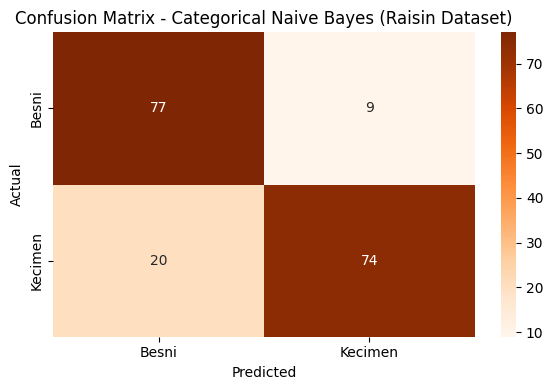

In [17]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import CategoricalNB
from sklearn.preprocessing import LabelEncoder, KBinsDiscretizer
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# === 1. Load dan Encode Target ===
# Load the data from the existing X and y variables
data = pd.concat([X, y], axis=1)

# Use the existing LabelEncoder 'le' that was fitted on the 'Class' column
le_class = le # Use the existing LabelEncoder from previous steps

# The 'class_encoded' column is already in the 'data' dataframe from previous steps

# === 2. Pisahkan Fitur dan Target ===
X_features = X.copy() # Use the original features
y_target = data['class_encoded']  # Use the encoded target from the combined dataframe

# === 3. Diskretisasi fitur numerik agar cocok untuk CategoricalNB ===
# Gunakan KBinsDiscretizer untuk mengubah fitur numerik menjadi kategorikal
discretizer = KBinsDiscretizer(n_bins=5, encode='ordinal', strategy='uniform')
X_discrete = discretizer.fit_transform(X_features)

# === 4. Split Data ===
X_train_nb, X_test_nb, y_train_nb, y_test_nb = train_test_split(
    X_discrete, y_target, test_size=0.2, random_state=42
)

# === 5. Training model Naive Bayes kategorikal ===
model = CategoricalNB()
model.fit(X_train_nb, y_train_nb)

# === 6. Evaluasi ===
y_pred_nb = model.predict(X_test_nb)
print("Akurasi:", accuracy_score(y_test_nb, y_pred_nb))
print("\n=== Classification Report ===")
print(classification_report(y_test_nb, y_pred_nb, target_names=le_class.classes_))

# === 7. Confusion Matrix ===
cm_nb = confusion_matrix(y_test_nb, y_pred_nb)

# Tampilkan sebagai tabel dan visualisasi
plt.figure(figsize=(6, 4))
sns.heatmap(cm_nb, annot=True, fmt='d', cmap='Oranges',
            xticklabels=le_class.classes_,
            yticklabels=le_class.classes_)
plt.title("Confusion Matrix - Categorical Naive Bayes (Raisin Dataset)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

### Modelling Klasifikasi Jenis Kismis (Raisin) Menggunakan K-Nearest Neighbors (KNN)

1. Tujuan Pemodelan

Tujuan dari pemodelan ini adalah untuk mengklasifikasikan jenis kismis menjadi salah satu dari dua kategori, yaitu:

- Besni
- Kecimen

berdasarkan fitur morfologis hasil ekstraksi citra biji kismis seperti luas area, panjang sumbu, kelengkungan, dan sebagainya.

Model yang digunakan adalah K-Nearest Neighbors (KNN), yaitu metode supervised learning berbasis jarak atau kedekatan antar data. Model ini bekerja dengan mencari sejumlah k tetangga terdekat dari data baru, lalu menentukan kelas mayoritas dari tetangga tersebut sebagai hasil prediksi.

2. Pembagian Dataset: Data Latih dan Data Uji

Data dibagi menjadi dua bagian utama:

* Data Latih (Training Set): digunakan untuk menyimpan data referensi.
* Data Uji (Testing Set): digunakan untuk menguji performa prediksi pada data baru.

Eksperimen ini menggunakan rasio pembagian 80:20, yaitu 80% data untuk pelatihan dan 20% untuk pengujian. Rasio ini dipilih untuk menjaga keseimbangan antara kapasitas belajar model dan evaluasi yang akurat.

3. Pra-Pemrosesan Data

Agar data dapat digunakan oleh model KNN, dilakukan tahapan preprocessing sebagai berikut:

- Label Encoding pada kolom Class untuk mengubah data kategorikal ('Besni' dan 'Kecimen') menjadi angka (0 dan 1).

- Tidak diperlukan transformasi fitur karena seluruh fitur seperti Area, Eccentricity, ConvexArea, dll. sudah berupa data numerik.

- (Opsional) Feature Scaling: Karena KNN menggunakan jarak (seperti Euclidean distance), sangat disarankan untuk melakukan normalisasi atau standarisasi agar semua fitur memiliki skala yang sama dan tidak mendistorsi perhitungan jarak.


4. Pelatihan Model K-Nearest Neighbors

Berbeda dengan model lain, KNN tidak melakukan pelatihan eksplisit. Model hanya menyimpan data latih. Saat prediksi, KNN akan:

1. Mengukur jarak antara data uji dengan seluruh data latih (umumnya menggunakan Euclidean distance).

2. Memilih k tetangga terdekat (dalam eksperimen ini, digunakan k = 5).

3. Menentukan hasil prediksi berdasarkan mayoritas kelas dari tetangga-tetangga tersebut.

Pemilihan nilai k yang optimal sangat penting untuk menghindari overfitting (jika terlalu kecil) atau underfitting (jika terlalu besar).


5. Evaluasi Model

MModel KNN dievaluasi dengan data uji menggunakan beberapa metrik evaluasi klasifikasi:

- Akurasi: Rasio prediksi benar dibandingkan dengan total data uji.

- Classification Report: Berisi:

1. Precision: Ketepatan model untuk masing-masing kelas (Besni, Kecimen)

2. Recall: Kemampuan model menangkap semua data yang benar dari setiap kelas

3. F1-Score: Rata-rata harmonis dari precision dan recall

- Confusion Matrix: Menunjukkan prediksi benar dan salah dari masing-masing kelas. Confusion matrix dapat divisualisasikan dalam bentuk heatmap agar lebih mudah dianalisis.


6. Prediksi dan Interpretasi

Setelah model KNN siap, model dapat digunakan untuk:

* Memprediksi jenis kismis baru berdasarkan data morfologis hasil pengukuran citra.

* Menganalisis data-data serupa (tetangga dekat) yang menyebabkan suatu prediksi, sehingga bisa dilihat pola morfologis umum untuk masing-masing jenis kismis.

* Mengukur sensitivitas prediksi terhadap nilai k dan jarak antar data.


Kesimpulan

K-Nearest Neighbors merupakan metode klasifikasi yang:

- Sederhana dan intuitif, sangat cocok untuk dataset dengan fitur numerik seperti Raisin Dataset.

- Tidak memerlukan pelatihan rumit, karena proses klasifikasi terjadi saat prediksi (lazy learner).

- Mudah disesuaikan dan ditingkatkan, misalnya dengan uji nilai k, jenis metrik jarak, dan teknik scaling fitur.

Namun, perlu diperhatikan bahwa KNN bisa menjadi lambat untuk dataset besar dan sangat bergantung pada skala fitur, sehingga normalisasi data menjadi aspek penting dalam implementasi.


Akurasi: 0.8277777777777777

=== Classification Report ===
              precision    recall  f1-score   support

       Besni       0.82      0.83      0.82        86
     Kecimen       0.84      0.83      0.83        94

    accuracy                           0.83       180
   macro avg       0.83      0.83      0.83       180
weighted avg       0.83      0.83      0.83       180



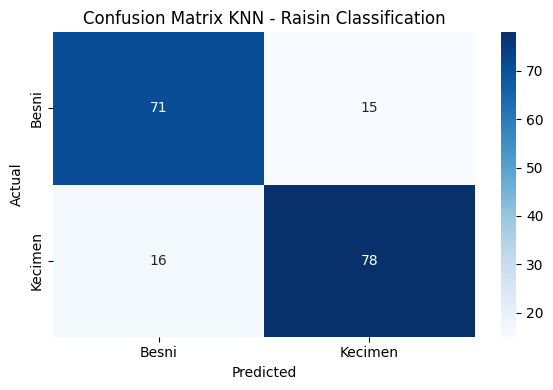

In [19]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# === 1. Load dan Pra-pemrosesan Dataset ===
# Use the existing X and y dataframes loaded from ucimlrepo
X_knn = X.copy()
y_knn = y.copy()

# Use the existing LabelEncoder 'le'
le_class = le # Use the existing LabelEncoder from previous steps

# === 2. Pisahkan Fitur dan Target (already done by using X and y) ===
# X = df.drop(columns=['Class', 'class_encoded']) # No need to drop columns from X
# y = df['class_encoded'] # y is already the encoded target

# === 3. Feature Scaling (Standarisasi) ===
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_knn)

# === 4. Split Dataset ===
X_train_knn, X_test_knn, y_train_knn, y_test_knn = train_test_split(
    X_scaled, y_knn, test_size=0.2, random_state=42
)

# === 5. Training KNN ===
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_knn, y_train_knn)

# === 6. Evaluasi Model ===
y_pred_knn = knn.predict(X_test_knn)
print("Akurasi:", accuracy_score(y_test_knn, y_pred_knn))
print("\n=== Classification Report ===")
print(classification_report(y_test_knn, y_pred_knn, target_names=le_class.classes_))

# === 7. Confusion Matrix ===
cm_knn = confusion_matrix(y_test_knn, y_pred_knn)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_knn, annot=True, fmt='d', cmap='Blues',
            xticklabels=le_class.classes_,
            yticklabels=le_class.classes_)
plt.title("Confusion Matrix KNN - Raisin Classification")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

## Evaluasi Data

Dari eksperimen klasifikasi jenis kismis menggunakan tiga model berbeda, diperoleh hasil akurasi sebagai berikut:

* Decision Tree = 83,89%
* Categorical Naive Bayes = 83,89%
* K-Nearest Neighbor = 82,78%

1. Decision Tree dan Categorical Naive Bayes sama-sama memiliki akurasi tertinggi, yaitu 83,89%.
2. KNN sedikit di bawah, dengan akurasi 82,78%.
3. Perbedaan antar model tidak besar, tapi menunjukkan bahwa:

- Model yang tidak terlalu bergantung pada jarak (seperti Decision Tree dan NB) lebih cocok untuk dataset Raisin ini.

- Fitur numerik Raisin yang beragam skala dapat memengaruhi performa KNN jika tidak di-scale dengan benar.
4. Tidak ada model yang >90%, artinya mungkin ada overlap atau kemiripan fitur antara jenis kismis Besni dan Kecimen.



##Deployment

#menyimpan model

In [23]:
import joblib

# misalnya model kamu bernama clf, dan scaler kamu bernama scaler
joblib.dump(clf, 'model_raisin.pkl')      # ini model
joblib.dump(scaler, 'scaler.pkl')         # ini scaler (kalau kamu pakai)

from google.colab import files

# Download model
files.download('model_raisin.pkl')

# Download scaler (kalau kamu simpan)
files.download('scaler.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Intgrasi Model dengan WEB

* Install library Streamlit, dengan menjalankan perintah “pip install streamlit” pada terminal.
* membuat file berekstensi .py, misal raisin.py. (sesuai dengan data kita)
* didalam raisin.py saya panggil model yang telah disimpan.
* setelah itu saya membuat tampilan informasi keterangan tentang inputan dan hasil evaluasi. selain itu saya juga membuat tampilan form untuk user menginputkan data yang akan diprediksi oleh model berserta tampilan untuk hasil prediksi. untuk tampilan saya masukkan code nya didalam file app.py juga, karena dimudahkan oleh library streamlit.

* Source code yang telah saya buat dapat diakses melalui link berikut :


Hasil web

https://kismisrahel.streamlit.app/

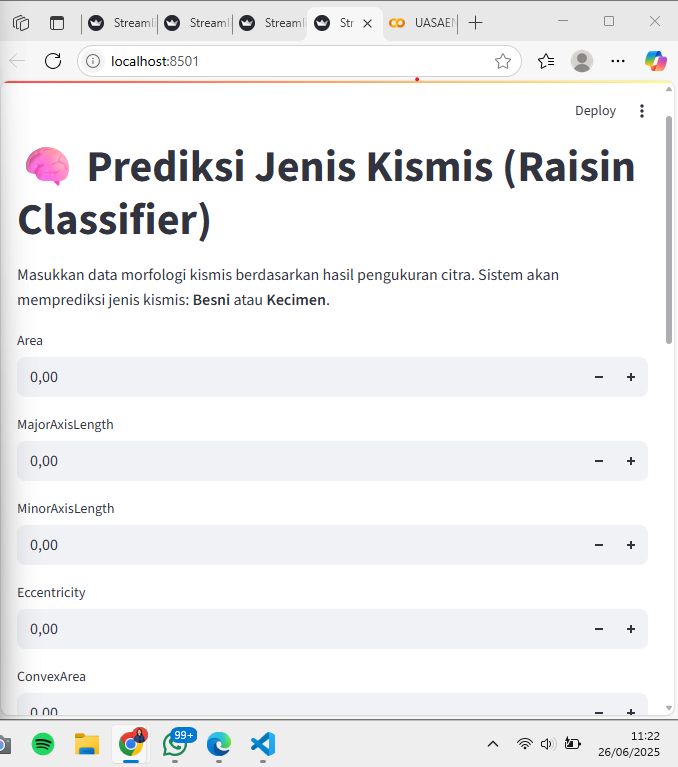

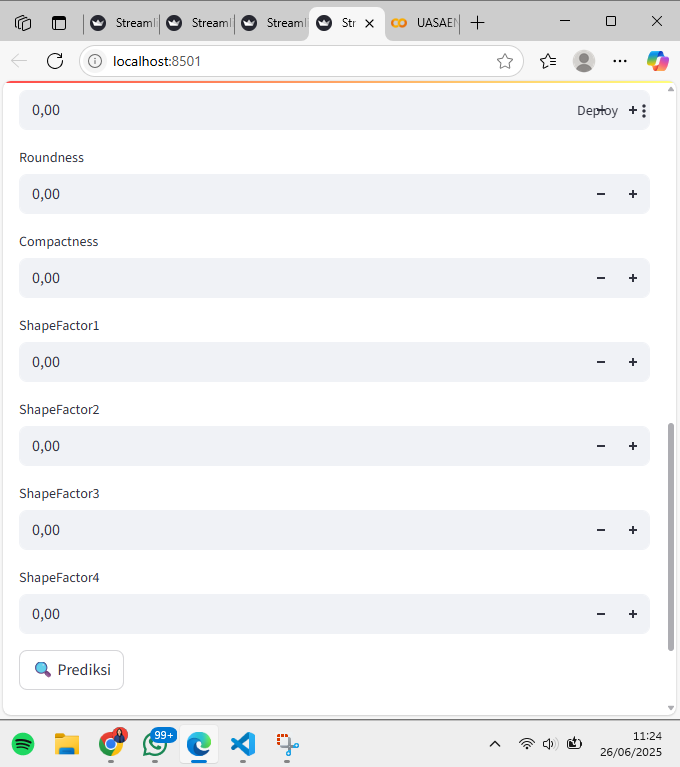